<a href="https://colab.research.google.com/github/Anuska111/Customer_Churn_Prevention_/blob/main/Customer_Churn_Prevention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn.csv to customer_churn.csv


In [5]:
df = pd.read_csv("customer_churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:

# Basic Information
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.head()

Shape: (7043, 33)

Data Types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: objec

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


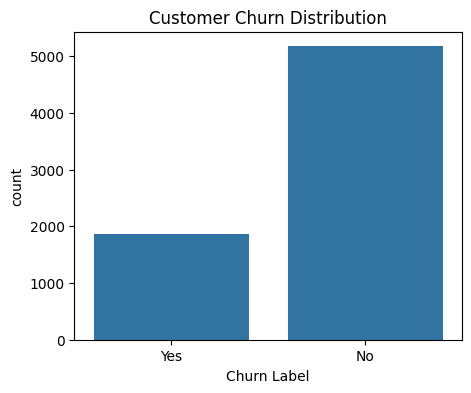

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.show()

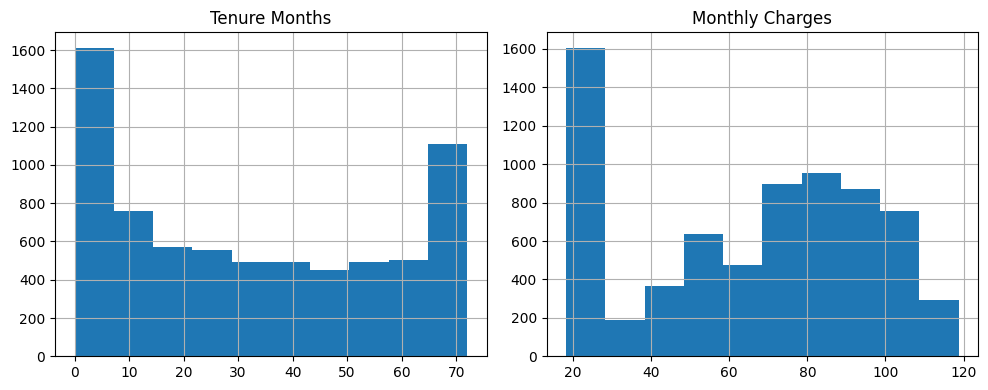

In [9]:
df[["Tenure Months","Monthly Charges","Total Charges"]].hist(figsize=(10,4))
plt.tight_layout()
plt.show()

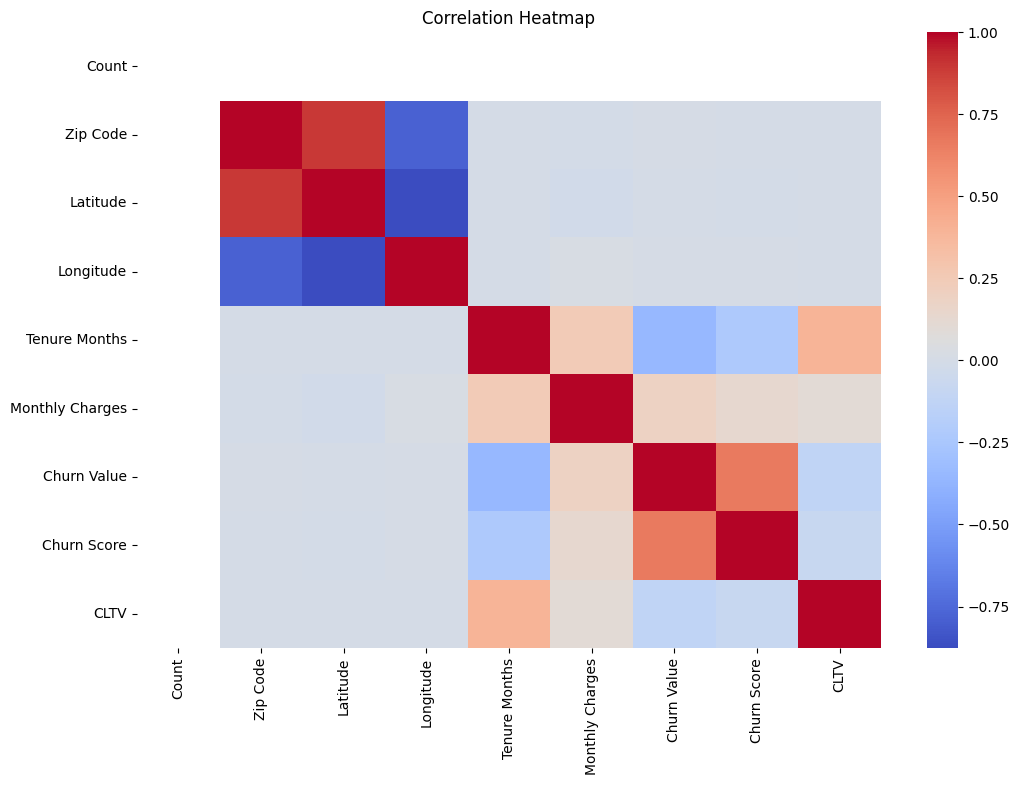

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [12]:
X = df.drop(["Churn Value", "Churn Label", "Churn Score", "Churn Reason"], axis=1)
y = df["Churn Value"]

In [13]:
df = df.drop([
    "CustomerID",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Score",
    "CLTV",
    "Churn Reason"
], axis=1)

In [14]:
print(df.columns)

Index(['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value'],
      dtype='object')


In [15]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [16]:
print(X.shape)
print(y.shape)

(7043, 21)
(7043,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 21)
(1409, 21)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Numerical and Categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV Accuracy: 0.999467455528045


In [33]:
print(X.columns.tolist())

['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [34]:
X = df.drop(["Churn Value", "Churn Label"], axis=1)
y = df["Churn Value"]

print(X.columns.tolist())

['Count', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [35]:
X = df.drop(["Churn Value", "Churn Label"], axis=1)
y = df["Churn Value"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Numerical and categorical columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

# Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Complete Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Hyperparameter Grid
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train Model
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV Accuracy: 0.8067070028258426


In [38]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.794889992902768
Precision: 0.6470588235294118
Recall   : 0.5
F1 Score : 0.5641025641025641


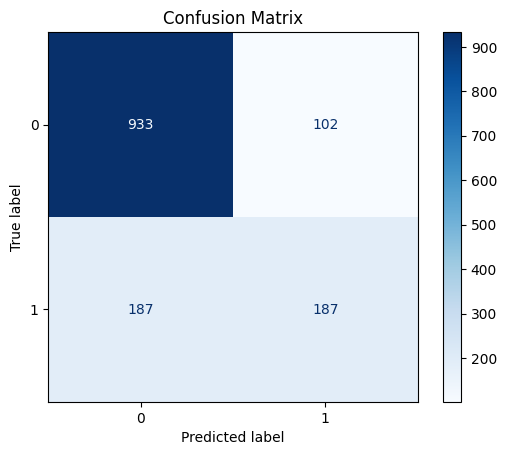

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409



In [41]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8384871735255367


In [42]:
import joblib

joblib.dump(best_model, "customer_churn_model.pkl")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [43]:
RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

RandomForestClassifier(class_weight='balanced', random_state=42)

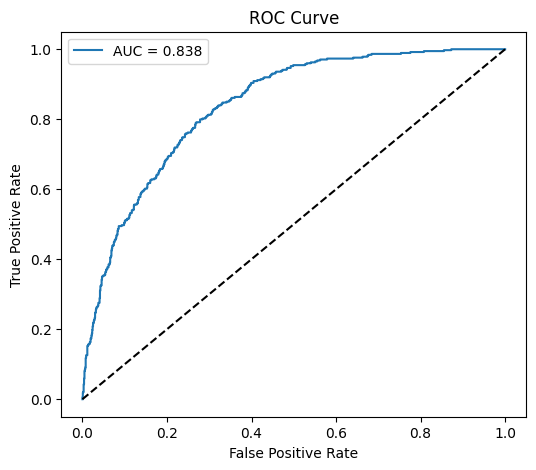

ROC-AUC Score: 0.8384871735255367


In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc)

In [45]:
import joblib

joblib.dump(best_model, "customer_churn_model.pkl")

print("✅ customer_churn_model.pkl saved successfully")

✅ customer_churn_model.pkl saved successfully


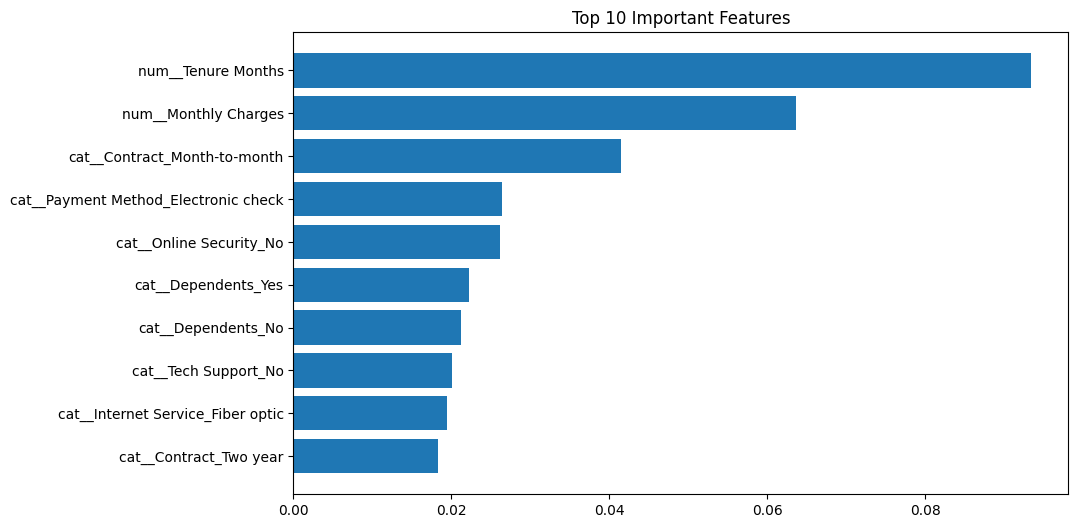

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [53]:
!pip install streamlit

In [55]:
import streamlit as st
import pandas as pd
import joblib

# Load trained pipeline
model = joblib.load("customer_churn_model.pkl")

st.set_page_config(page_title="Customer Churn Prediction", page_icon="📊")

st.title("📊 Customer Churn Prediction")
st.write("Enter customer details to predict whether the customer is likely to churn.")

# User Inputs
gender = st.selectbox("Gender", ["Male", "Female"])
senior = st.selectbox("Senior Citizen", [0, 1])
partner = st.selectbox("Partner", ["Yes", "No"])
dependents = st.selectbox("Dependents", ["Yes", "No"])
tenure = st.number_input("Tenure Months", min_value=0, max_value=100, value=12)
phone = st.selectbox("Phone Service", ["Yes", "No"])
multiple = st.selectbox("Multiple Lines", ["Yes", "No", "No phone service"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
backup = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])
device = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])
tech = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])
tv = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])
movies = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])
contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
paperless = st.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.selectbox(
    "Payment Method",
    ["Electronic check", "Mailed check",
     "Bank transfer (automatic)", "Credit card (automatic)"]
)
monthly = st.number_input("Monthly Charges", min_value=0.0, value=70.0)
total = st.number_input("Total Charges", min_value=0.0, value=1000.0)

if st.button("Predict Churn"):
    data = pd.DataFrame({
        "Gender":[gender],
        "Senior Citizen":[senior],
        "Partner":[partner],
        "Dependents":[dependents],
        "Tenure Months":[tenure],
        "Phone Service":[phone],
        "Multiple Lines":[multiple],
        "Internet Service":[internet],
        "Online Security":[security],
        "Online Backup":[backup],
        "Device Protection":[device],
        "Tech Support":[tech],
        "Streaming TV":[tv],
        "Streaming Movies":[movies],
        "Contract":[contract],
        "Paperless Billing":[paperless],
        "Payment Method":[payment],
        "Monthly Charges":[monthly],
        "Total Charges":[total]
    })

2026-07-29 10:39:00.106 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 10:39:00.108 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 10:39:00.380 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-29 10:39:00.381 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 10:39:00.382 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 10:39:00.384 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-29 10:39:00.385 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn